In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import torch
import random  # <-- IMPORT MANCANTE AGGIUNTO
import numpy as np
from PIL import Image
from torch.utils.data import Dataset

class MFNetDataset(Dataset):
    def __init__(self, base_path, split_list, transform=None, mode='train', drop_prob=0):
        """
        split_list: può essere il percorso di un file .txt (es. 'train.txt')
                    oppure una lista Python di nomi di file (es. ['0001D', '0002D', ...])
        """
        self.img_dir = os.path.join(base_path, "images")
        self.mask_dir = os.path.join(base_path, "labels")
        self.transform = transform
        self.mode = mode
        self.drop_prob = drop_prob

        # 1. GESTIONE DEGLI SPLIT (Evita il Data Leakage)
        if isinstance(split_list, str) and split_list.endswith('.txt'):
            # Se passi un file .txt, lo legge
            with open(split_list, 'r') as f:
                # Legge le righe, toglie gli spazi e rimuove estensioni se presenti
                self.common_names = [line.strip().replace('.png', '') for line in f.readlines()]
        elif isinstance(split_list, list):
            # Se passi già una lista di nomi, la usa direttamente
            self.common_names = split_list
        else:
            raise ValueError("split_list deve essere una lista o il percorso di un file .txt")

        # Rimuoviamo eventuali nomi vuoti sfuggiti
        self.common_names = [name for name in self.common_names if name]

        print(f"Dataset inizializzato in modalità '{self.mode}': {len(self.common_names)} immagini trovate.")

    def __len__(self):
        return len(self.common_names)

    def __getitem__(self, idx):
        base_name = self.common_names[idx]

        img_path = os.path.join(self.img_dir, base_name + ".png")
        mask_path = os.path.join(self.mask_dir, base_name + ".png")

        # Open the raw image keeping all 4 channels (RGBA)
        img_rgba = Image.open(img_path)

        # Extract Visual image (first 3 channels: RGB)
        img_visual = img_rgba.convert('RGB')

        # Extract Thermal image (Alpha channel) and convert to 3-channel RGB
        img_thermal = img_rgba.getchannel('A').convert('RGB')

        # Load and prepare the mask
        img_mask = Image.open(mask_path).convert('L')
        mask_np = np.array(img_mask)
        tensor_mask = torch.as_tensor(mask_np, dtype=torch.long)

        # Apply transformations (Attenzione: vale solo per ToTensor o ColorJitter, NON per geometriche)
        if self.transform:
            tensor_thermal = self.transform(img_thermal)
            tensor_visual = self.transform(img_visual)
        else:
            tensor_thermal = img_thermal
            tensor_visual = img_visual

        # MODAL DROPOUT (Solo in fase di addestramento)
        if self.mode == 'train' and self.drop_prob > 0:
            rand_val = random.random() # Ora funzionerà grazie all'import in alto!

            # 1. Drop Thermal, Keep RGB (probabilità = drop_prob)
            if rand_val < self.drop_prob:
                tensor_thermal = torch.zeros_like(tensor_thermal)

            # 2. Drop RGB, Keep Thermal (probabilità = drop_prob)
            elif rand_val < (2 * self.drop_prob):
                tensor_visual = torch.zeros_like(tensor_visual)

        return tensor_thermal, tensor_visual, tensor_mask

In [3]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/archive.zip"
extract_dir = "/content/data/extracted_dataset" # Creiamo una cartella pulita per l'estrazione

os.makedirs(extract_dir, exist_ok=True)

print("Estrazione in corso... (potrebbe volerci qualche istante per le immagini)")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)
print("Estrazione completata!")

base_path = "/content/data/extracted_dataset/MFNet-dataset/ir_seg_dataset"

print(f"Il tuo nuovo base_path pronto all'uso è:\\n{base_path}")

Estrazione in corso... (potrebbe volerci qualche istante per le immagini)
Estrazione completata!
Il tuo nuovo base_path pronto all'uso è:\n/content/data/extracted_dataset/MFNet-dataset/ir_seg_dataset


Trovate 1569 immagini complete (con maschera).
Divisione completata: 1255 Train, 157 Val, 157 Test.
Dataset inizializzato in modalità 'train': 1255 immagini trovate.
Dataset inizializzato in modalità 'test': 157 immagini trovate.
Dataset inizializzato in modalità 'test': 157 immagini trovate.


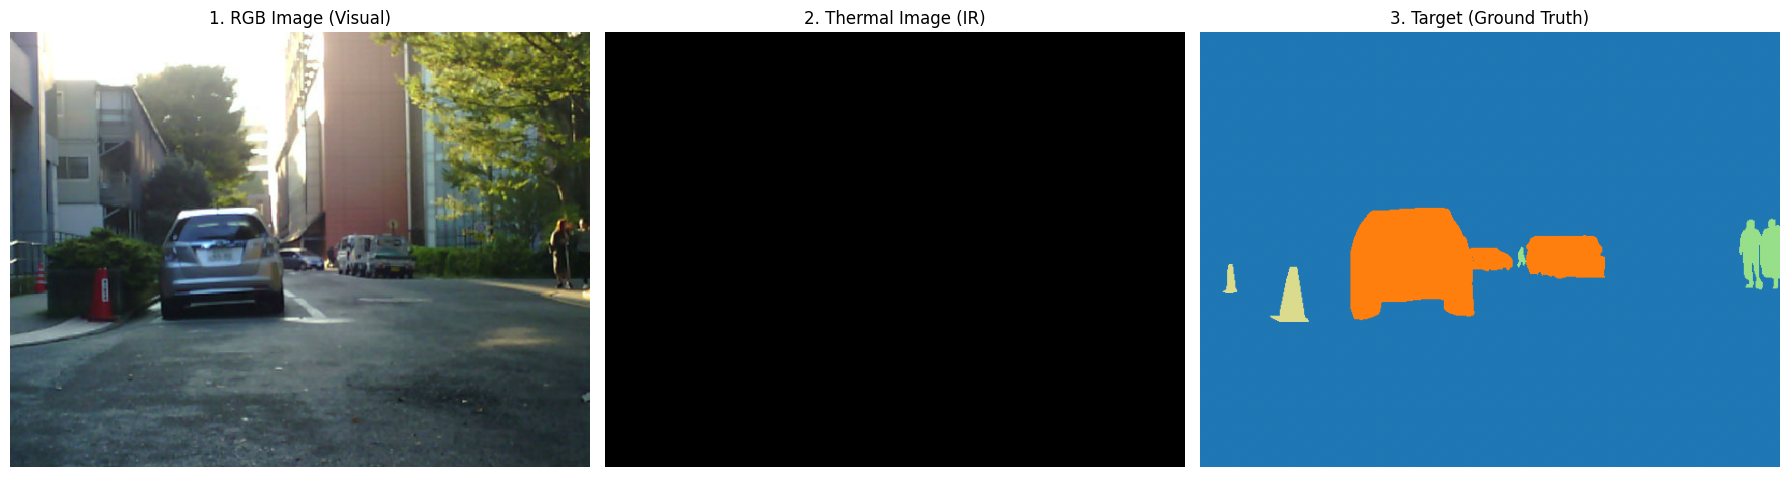

Valore massimo RGB: 1.0000
Valore massimo Termica: 0.0000


In [4]:
import matplotlib.pyplot as plt
import random
from torchvision import transforms
from sklearn.model_selection import train_test_split # <-- Importante per dividere il dataset

# 1. RECUPERIAMO SOLO I FILE CHE HANNO SIA L'IMMAGINE CHE LA MASCHERA
img_dir = os.path.join(base_path, "images")
mask_dir = os.path.join(base_path, "labels")

# Prendiamo i nomi senza estensione da entrambe le cartelle
immagini = {f.replace('.png', '') for f in os.listdir(img_dir) if f.endswith('.png')}
etichette = {f.replace('.png', '') for f in os.listdir(mask_dir) if f.endswith('.png')}

# L'intersezione tiene SOLO i file presenti in entrambi gli insiemi
tutti_i_file = sorted(list(immagini.intersection(etichette)))

print(f"Trovate {len(tutti_i_file)} immagini complete (con maschera).")

# 2. DIVIDIAMO IL DATASET (80% Train, 10% Val, 10% Test)
train_names, temp_names = train_test_split(tutti_i_file, test_size=0.2, random_state=42)
val_names, test_names = train_test_split(temp_names, test_size=0.5, random_state=42)

print(f"Divisione completata: {len(train_names)} Train, {len(val_names)} Val, {len(test_names)} Test.")

# 3. INIZIALIZZIAMO TUTTI E 3 I DATASET CON LE 'split_list' CORRETTE
transform = transforms.ToTensor()

dataset_training = MFNetDataset(
    base_path=base_path,
    split_list=train_names,
    transform=transform,
    mode='train',
    drop_prob=0.2            # Aggiungiamo un 20% di probabilità di spegnere RGB/Termica
)

dataset_val = MFNetDataset(
    base_path=base_path,
    split_list=val_names,
    transform=transform,
    mode='test',             # Mettiamo 'test' per disattivare il drop_prob!
    drop_prob=0.0            # Niente dropout durante la validazione
)

# ECCO IL PEZZO CHE MANCAVA!
dataset_test = MFNetDataset(
    base_path=base_path,
    split_list=test_names,
    transform=transform,
    mode='test',
    drop_prob=0.0
)

# 4. PLOT DI UNA IMMAGINE CASUALE
random_index = random.randint(0, len(dataset_training) - 1)
img_thermal, img_visual, true_mask = dataset_training[random_index]

# Prepare images for Matplotlib
img_t_plot = img_thermal.permute(1, 2, 0).numpy()
img_v_plot = img_visual.permute(1, 2, 0).numpy()
mask_plot = true_mask.numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# COLUMN 1: Visual Image (RGB)
axes[0].imshow(img_v_plot)
axes[0].set_title("1. RGB Image (Visual)")
axes[0].axis('off')

# COLUMN 2: Thermal Image
axes[1].imshow(img_t_plot)
axes[1].set_title("2. Thermal Image (IR)")
axes[1].axis('off')

# COLUMN 3: Target Mask
axes[2].imshow(mask_plot, cmap='tab20', vmin=0, vmax=8)
axes[2].set_title("3. Target (Ground Truth)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f"Valore massimo RGB: {img_visual.max().item():.4f}")
print(f"Valore massimo Termica: {img_thermal.max().item():.4f}")

In [5]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()

        self.conv_block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        x = self.conv_block(x)
        return x


class UNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=9):
        super(UNet, self).__init__()

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.down1 = DoubleConv(in_channels, 64)
        self.down2 = DoubleConv(64, 128)
        self.down3 = DoubleConv(128, 256)
        self.down4 = DoubleConv(256, 512)

        self.bottleneck = DoubleConv(512, 1024)

        self.up1 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.up_conv1 = DoubleConv(1024, 512)

        self.up2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.up_conv2 = DoubleConv(512, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.up_conv3 = DoubleConv(256, 128)

        self.up4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.up_conv4 = DoubleConv(128, 64)

        self.final_conv = nn.Conv2d(64, num_classes, kernel_size=1)


    def forward(self, x):
        # ENCODER
        x1 = self.down1(x)
        p1 = self.pool(x1)

        x2 = self.down2(p1)
        p2 = self.pool(x2)

        x3 = self.down3(p2)
        p3 = self.pool(x3)

        x4 = self.down4(p3)
        p4 = self.pool(x4)

        b = self.bottleneck(p4)

        # DECODER

        u1 = self.up1(b)
        concat1 = torch.cat([x4, u1], dim=1)
        d1 = self.up_conv1(concat1)

        u2 = self.up2(d1)
        concat2 = torch.cat([x3, u2], dim=1)
        d2 = self.up_conv2(concat2)

        u3 = self.up3(d2)
        concat3 = torch.cat([x2, u3], dim=1)
        d3 = self.up_conv3(concat3)

        u4 = self.up4(d3)
        concat4 = torch.cat([x1, u4], dim=1)
        d4 = self.up_conv4(concat4)

        out = self.final_conv(d4)

        return out


class DualNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=9):
        super(DualNet, self).__init__()

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.down1_rgb = DoubleConv(in_channels, 64)
        self.down2_rgb = DoubleConv(64, 128)
        self.down3_rgb = DoubleConv(128, 256)
        self.down4_rgb = DoubleConv(256, 512)

        self.down1_thermal = DoubleConv(in_channels, 64)
        self.down2_thermal = DoubleConv(64, 128)
        self.down3_thermal = DoubleConv(128, 256)
        self.down4_thermal = DoubleConv(256, 512)

        self.bottleneck = DoubleConv(1024, 1024)

        self.up1 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.up_conv1 = DoubleConv(1024, 512)

        self.up2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.up_conv2 = DoubleConv(512, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.up_conv3 = DoubleConv(256, 128)

        self.up4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.up_conv4 = DoubleConv(128, 64)

        self.final_conv = nn.Conv2d(64, num_classes, kernel_size=1)


    def forward(self, x_rgb, x_thermal):
        # ENCODER
        x1_rgb = self.down1_rgb(x_rgb)
        p1_rgb = self.pool(x1_rgb)

        x2_rgb = self.down2_rgb(p1_rgb)
        p2_rgb = self.pool(x2_rgb)

        x3_rgb = self.down3_rgb(p2_rgb)
        p3_rgb = self.pool(x3_rgb)

        x4_rgb = self.down4_rgb(p3_rgb)
        p4_rgb = self.pool(x4_rgb)

        x1_thermal = self.down1_thermal(x_thermal)
        p1_thermal = self.pool(x1_thermal)

        x2_thermal = self.down2_thermal(p1_thermal)
        p2_thermal = self.pool(x2_thermal)

        x3_thermal = self.down3_thermal(p2_thermal)
        p3_thermal = self.pool(x3_thermal)

        x4_thermal = self.down4_thermal(p3_thermal)
        p4_thermal = self.pool(x4_thermal)

        bn_input = torch.cat([p4_rgb, p4_thermal], dim=1)
        b = self.bottleneck(bn_input)

        skip4 = x4_rgb + x4_thermal
        skip3 = x3_rgb + x3_thermal
        skip2 = x2_rgb + x2_thermal
        skip1 = x1_rgb + x1_thermal

        # DECODER

        u1 = self.up1(b)
        concat1 = torch.cat([skip4, u1], dim=1)
        d1 = self.up_conv1(concat1)

        u2 = self.up2(d1)
        concat2 = torch.cat([skip3, u2], dim=1)
        d2 = self.up_conv2(concat2)

        u3 = self.up3(d2)
        concat3 = torch.cat([skip2, u3], dim=1)
        d3 = self.up_conv3(concat3)

        u4 = self.up4(d3)
        concat4 = torch.cat([skip1, u4], dim=1)
        d4 = self.up_conv4(concat4)

        out = self.final_conv(d4)

        return out

In [6]:
import os
import torch
import torch.nn as nn
import torch.optim as optim

def train_model(modality, model, train_loader, val_loader, epochs=15, lr=0.0001, save_dir="/content/drive/MyDrive/modelli_salvati", resume_path=None):
    """
    Funzione universale di addestramento.
    modality: può essere 'rgb', 'thermal', o 'dual'
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"\n🚀 INIZIO ADDESTRAMENTO: MODELLO {modality.upper()} su {device} 🚀")

    if torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)

    model = model.to(device)

    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, f"best_model_{modality}.pth") # Nome generico

    weights = torch.tensor([0.1, 1.5, 2.0, 2.0, 1.0, 1.0, 1.0, 1.5, 1.5]).to(device)
    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Variabili di partenza di default
    start_epoch = 0
    best_val_loss = float('inf')

    # ==========================================
    # LOGICA DI RESUME (RIPRISTINO CHECKPOINT)
    # ==========================================
    if resume_path and os.path.exists(resume_path):
        print(f"🔄 Trovato checkpoint! Ripristino da: {resume_path}")
        checkpoint = torch.load(resume_path)

        if isinstance(model, nn.DataParallel):
            model.module.load_state_dict(checkpoint['model_state_dict'])
        else:
            model.load_state_dict(checkpoint['model_state_dict'])

        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_val_loss = checkpoint['best_val_loss']
        print(f"▶️ Ripresa dall'epoca {start_epoch+1} (Miglior Val Loss precedente: {best_val_loss:.4f})")
    # ==========================================

    for epoch in range(start_epoch, epochs):

        # --- FASE DI TRAINING ---
        model.train()
        train_loss = 0.0

        for batch_idx, (img_thermal, img_visual, true_mask) in enumerate(train_loader):
            img_thermal, img_visual, true_mask = img_thermal.to(device), img_visual.to(device), true_mask.to(device)

            optimizer.zero_grad()

            # 🟢 GESTIONE INTELLIGENTE DEGLI INPUT
            if modality == 'rgb':
                predictions = model(img_visual)
            elif modality == 'thermal':
                predictions = model(img_thermal)
            elif modality == 'dual':
                # NOTA: Assicurati che il forward della tua DualNet accetti prima RGB e poi Termica
                # Se è il contrario, inverti i parametri qui sotto!
                predictions = model(img_visual, img_thermal)
            else:
                raise ValueError("La modalità deve essere 'rgb', 'thermal' o 'dual'")

            loss = criterion(predictions, true_mask)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        # --- FASE DI VALIDAZIONE ---
        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for img_thermal, img_visual, true_mask in val_loader:
                img_thermal, img_visual, true_mask = img_thermal.to(device), img_visual.to(device), true_mask.to(device)

                # 🟢 STESSA LOGICA PER LA VALIDAZIONE
                if modality == 'rgb':
                    predictions = model(img_visual)
                elif modality == 'thermal':
                    predictions = model(img_thermal)
                elif modality == 'dual':
                    predictions = model(img_visual, img_thermal)

                loss = criterion(predictions, true_mask)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)

        print(f"Epoch [{epoch+1:02d}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

        # --- CHECKPOINTING COMPLETO ---
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss

            checkpoint = {
                'epoch': epoch,
                'model_state_dict': model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_val_loss': best_val_loss
            }
            torch.save(checkpoint, save_path)
            print(f"   ⭐ Modello e ottimizzatore salvati su Drive in -> {save_path}")

    print(f"✅ Addestramento {modality.upper()} completato!\n")
    return model

In [7]:
from torch.utils.data import DataLoader

# 1. Crea tutti e tre i DataLoader separati
dataloader_train = DataLoader(dataset_training, batch_size=4, shuffle=True, num_workers=2)

# Per Val e Test mettiamo shuffle=False perché non serve mischiare
dataloader_val = DataLoader(dataset_val, batch_size=4, shuffle=False, num_workers=2)
dataloader_test = DataLoader(dataset_test, batch_size=4, shuffle=False, num_workers=2)

# ================================
# ADDESTRIAMO IL MODELLO RGB
# ================================
model_rgb = UNet(in_channels=3, num_classes=9)
#train_model(
 #   modality='rgb',
  #  model=model_rgb,
   # train_loader=dataloader_train,
 #   val_loader=dataloader_val,  # <--- Passiamo SOLO quello di validazione!
 #   epochs=15,
 #   resume_path="/content/drive/MyDrive/3dPerceptionModels/modelli_salvati/best_unet_rgb.pth"
#)

# ================================
# ADDESTRIAMO IL MODELLO TERMICO
# ================================
#model_thermal = UNet(in_channels=3, num_classes=9)
#train_model(
 #   modality='thermal',
  #  model=model_thermal,
  #  train_loader=dataloader_train,
  #  val_loader=dataloader_val,  # <--- Passiamo SOLO quello di validazione!
   # epochs=15,
    #resume_path="/content/drive/MyDrive/3dPerceptionModels/modelli_salvati/best_unet_thermal.pth"
#)

model_dual = DualNet(in_channels=3, num_classes=9)
train_model(
    modality='dual',
    model=model_dual,
    train_loader=dataloader_train,
    val_loader=dataloader_val,
    epochs=15,
    resume_path="/content/drive/MyDrive/modelli_salvati/best_model_dual.pth"

)


🚀 INIZIO ADDESTRAMENTO: MODELLO DUAL su cuda 🚀
🔄 Trovato checkpoint! Ripristino da: /content/drive/MyDrive/modelli_salvati/best_model_dual.pth
▶️ Ripresa dall'epoca 7 (Miglior Val Loss precedente: 0.8377)
Epoch [07/15] | Train Loss: 0.8378 | Val Loss: 0.7575
   ⭐ Modello e ottimizzatore salvati su Drive in -> /content/drive/MyDrive/modelli_salvati/best_model_dual.pth
Epoch [08/15] | Train Loss: 0.8117 | Val Loss: 0.7889
Epoch [09/15] | Train Loss: 0.8005 | Val Loss: 0.7963
Epoch [10/15] | Train Loss: 0.7507 | Val Loss: 0.6914
   ⭐ Modello e ottimizzatore salvati su Drive in -> /content/drive/MyDrive/modelli_salvati/best_model_dual.pth
Epoch [11/15] | Train Loss: 0.7359 | Val Loss: 0.6866
   ⭐ Modello e ottimizzatore salvati su Drive in -> /content/drive/MyDrive/modelli_salvati/best_model_dual.pth
Epoch [12/15] | Train Loss: 0.6922 | Val Loss: 0.6160
   ⭐ Modello e ottimizzatore salvati su Drive in -> /content/drive/MyDrive/modelli_salvati/best_model_dual.pth
Epoch [13/15] | Train Loss

DualNet(
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (down1_rgb): DoubleConv(
    (conv_block): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down2_rgb): DoubleConv(
    (conv_block): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(

In [ ]:
import torch
import numpy as np

def evaluate_late_fusion(model_rgb, model_thermal, test_loader, num_classes=9):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print("🚀 Inizio valutazione globale sul Test Set...")

    # Assicuriamoci che i modelli siano in modalità valutazione
    model_rgb.eval()
    model_thermal.eval()

    metodi = [
        "RGB Only",
        "Thermal Only",
        "FUSION (Average)",
        "FUSION (Product)",
        "FUSION (Max)"
    ]

    # Dizionari per accumulare intersezioni e unioni per tutto il dataset
    intersezioni_globali = {m: np.zeros(num_classes) for m in metodi}
    unioni_globali = {m: np.zeros(num_classes) for m in metodi}

    with torch.no_grad(): # Nessun calcolo dei gradienti in test!
        for batch_idx, (img_thermal, img_visual, true_mask) in enumerate(test_loader):

            img_thermal = img_thermal.to(device)
            img_visual = img_visual.to(device)
            true_mask = true_mask.cpu().numpy() # Spostiamo la Ground Truth su CPU per Numpy

            # --- 1. Otteniamo i logits dai modelli ---
            logits_rgb = model_rgb(img_visual)
            logits_thermal = model_thermal(img_thermal)

            # --- 2. Convertiamo in Probabilità con Softmax ---
            prob_rgb = torch.softmax(logits_rgb, dim=1)
            prob_thermal = torch.softmax(logits_thermal, dim=1)

            # --- 3. Prepariamo le predizioni per tutti i metodi ---
            preds = {}
            preds["RGB Only"] = torch.argmax(prob_rgb, dim=1).cpu().numpy()
            preds["Thermal Only"] = torch.argmax(prob_thermal, dim=1).cpu().numpy()
            preds["FUSION (Average)"] = torch.argmax((prob_rgb + prob_thermal) / 2.0, dim=1).cpu().numpy()
            preds["FUSION (Product)"] = torch.argmax(prob_rgb * prob_thermal, dim=1).cpu().numpy()
            preds["FUSION (Max)"] = torch.argmax(torch.max(prob_rgb, prob_thermal), dim=1).cpu().numpy()

            # --- 4. Accumuliamo Intersezione e Unione per il batch ---
            for m in metodi:
                pred_mask = preds[m]

                for c in range(num_classes):
                    pred_c = (pred_mask == c)
                    true_c = (true_mask == c)

                    intersezioni_globali[m][c] += np.logical_and(pred_c, true_c).sum()
                    unioni_globali[m][c] += np.logical_or(pred_c, true_c).sum()

    # --- 5. CALCOLO FINALE E STAMPA ---
    print("\n" + "="*50)
    print("📊 RISULTATI GLOBALI mIoU SUL TEST SET 📊")
    print("="*50)

    for m in metodi:
        global_ious = []

        for c in range(num_classes):
            if unioni_globali[m][c] == 0:
                # Se la classe non esiste né nelle predizioni né nella GT
                global_ious.append(np.nan)
            else:
                iou_c = intersezioni_globali[m][c] / unioni_globali[m][c]
                global_ious.append(iou_c)

        # Calcoliamo la media ignorando le classi NaN
        miou_finale = np.nanmean(global_ious)

        print(f"🥇 {m:18s} -> mIoU: {miou_finale:.4f}")

    print("="*50 + "\n")

In [ ]:
import torch

# 1. Definiamo il device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Test in esecuzione su: {device}")

# 2. Inizializziamo le architetture vuote
# (Assicurati di aver prima eseguito la cella con la definizione della classe UNet)
model_rgb_test = UNet(in_channels=3, num_classes=9).to(device)
model_thermal_test = UNet(in_channels=3, num_classes=9).to(device)

# 3. Definiamo i percorsi dei file salvati su Drive
# ⚠️ ATTENZIONE: Se li avevi rinominati per distinguere quelli con/senza Data Augmentation,
# ricordati di aggiornare il nome del file qui sotto!
percorso_rgb = "/content/drive/MyDrive/3dPerceptionModels/modelli_salvati/best_unet_rgb.pth"
percorso_thermal = "/content/drive/MyDrive/3dPerceptionModels/modelli_salvati/best_unet_thermal.pth"

# 4. Carichiamo i pesi
print("Caricamento pesi modello RGB...")
checkpoint_rgb = torch.load(percorso_rgb, map_location=device)
model_rgb_test.load_state_dict(checkpoint_rgb['model_state_dict'])

print("Caricamento pesi modello Termico...")
checkpoint_thermal = torch.load(percorso_thermal, map_location=device)
model_thermal_test.load_state_dict(checkpoint_thermal['model_state_dict'])

print("✅ Modelli caricati con successo! Avvio del test...")

# 5. Chiamiamo la funzione che hai appena definito!
evaluate_late_fusion(
    model_rgb=model_rgb_test,
    model_thermal=model_thermal_test,
    test_loader=dataloader_test,
    num_classes=9
)

Test in esecuzione su: cuda
Caricamento pesi modello RGB...
Caricamento pesi modello Termico...
✅ Modelli caricati con successo! Avvio del test...
🚀 Inizio valutazione globale sul Test Set...

📊 RISULTATI GLOBALI mIoU SUL TEST SET 📊
🥇 RGB Only           -> mIoU: 0.2356
🥇 Thermal Only       -> mIoU: 0.2066
🥇 FUSION (Average)   -> mIoU: 0.2713
🥇 FUSION (Product)   -> mIoU: 0.2827
🥇 FUSION (Max)       -> mIoU: 0.2565



In [8]:
import numpy as np
import torch

def evaluate_dualnet(model, test_loader, num_classes=9):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print("🚀 Inizio valutazione globale della DUALNET sul Test Set...")

    model.eval()

    # Array per accumulare intersezioni e unioni
    intersections_np = np.zeros(num_classes)
    unions_np = np.zeros(num_classes)

    with torch.no_grad():
        for batch_idx, (img_thermal, img_visual, true_mask) in enumerate(test_loader):

            img_thermal = img_thermal.to(device)
            img_visual = img_visual.to(device)
            true_mask = true_mask.cpu().numpy()

            # 1. Forward pass diretto con entrambi gli input
            logits = model(img_visual, img_thermal)

            # 2. Otteniamo la maschera predetta
            pred_mask = torch.argmax(logits, dim=1).cpu().numpy()

            # 3. Accumuliamo per ogni classe
            for c in range(num_classes):
                pred_c = (pred_mask == c)
                true_c = (true_mask == c)

                intersections_np[c] += np.logical_and(pred_c, true_c).sum()
                unions_np[c] += np.logical_or(pred_c, true_c).sum()

    # --- CALCOLO FINALE E STAMPA ---
    print("\n" + "="*45)
    print("📊 RISULTATI GLOBALI mIoU DUALNET 📊")
    print("="*45)

    global_ious = []
    for c in range(num_classes):
        if unions_np[c] == 0:
            global_ious.append(np.nan)
            print(f"Classe {c}: Non presente nel dataset")
        else:
            iou_c = intersections_np[c] / unions_np[c]
            global_ious.append(iou_c)
            print(f"Classe {c}: {iou_c:.4f}")

    # La media finale (ignorando eventuali NaN)
    miou_finale = np.nanmean(global_ious)

    print("-" * 45)
    print(f"🥇 GLOBAL mIoU DELLA DUALNET: {miou_finale:.4f}")
    print("-" * 45 + "\n")

In [9]:
import torch

# 1. Definiamo il device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Test in esecuzione su: {device}")

# 2. Inizializziamo l'architettura vuota per la DualNet
# (Assicurati di aver prima eseguito la cella con la definizione della classe DualNet)
model_dual_test = DualNet(in_channels=3, num_classes=9).to(device)

# 3. Definiamo il percorso del file salvato su Drive
# ⚠️ ATTENZIONE: Controlla che il nome del file corrisponda a quello generato
# dalla funzione di addestramento (se hai usato modality='dual', di default sarà best_model_dual.pth)
percorso_dual = "/content/drive/MyDrive/modelli_salvati/best_model_dual.pth"

# 4. Carichiamo i pesi dal checkpoint
print("Caricamento pesi modello DualNet in corso...")
try:
    checkpoint_dual = torch.load(percorso_dual, map_location=device)
    model_dual_test.load_state_dict(checkpoint_dual['model_state_dict'])
    print("✅ Modello caricato con successo! Avvio del test...")

    # 5. Chiamiamo la funzione di valutazione
    evaluate_dualnet(
        model=model_dual_test,
        test_loader=dataloader_test,
        num_classes=9
    )
except FileNotFoundError:
    print(f"❌ Errore: Impossibile trovare il file in {percorso_dual}.")
    print("Controlla su Google Drive il nome esatto del file salvato e aggiorna la variabile 'percorso_dual'.")

Test in esecuzione su: cuda
Caricamento pesi modello DualNet in corso...
✅ Modello caricato con successo! Avvio del test...
🚀 Inizio valutazione globale della DUALNET sul Test Set...

📊 RISULTATI GLOBALI mIoU DUALNET 📊
Classe 0: 0.8744
Classe 1: 0.4196
Classe 2: 0.2229
Classe 3: 0.2355
Classe 4: 0.2560
Classe 5: 0.0101
Classe 6: 0.0000
Classe 7: 0.0944
Classe 8: 0.0929
---------------------------------------------
🥇 GLOBAL mIoU DELLA DUALNET: 0.2451
---------------------------------------------

